# **Tugas Mandiri: Visualisasi Data Multivariat**

Aprilia Safna Anggraeni (24031554003) - 2024 A

## **Dataset**

Dataset yang digunakan dalan analisis Visualisasi Data Multivariat ini adalah **Dataset berjudul Chicago Crime 2015-2020**. Dataset ini bersumber dari **dataset publik Kaggle**. **Dataset Chicago Crime** ini bersumber dari **Chicago Police Department** yang berdisi data mengenai k**ejadian kriminal yang dilaporkan di kota Chicago**. Data ini dikumpulkan oleh Polisi kota Chicago yang disimpan dalam sistem CLEAR (Citizen Law Enforcement Analysis and Reporting). Data dalam dataset ini digunakan untuk monitoring crime, analisis keamanan kota, dan kebijakan publik.

**Dataset Chicago Crime** ini berisi data dengan periode waktu **Tahun 2015-2020**, **7 variabel**, dan **70.748 data**. 7 Variabel dalam dataset yaitu:
1. **primary_type**: Variabel yang menunjukkan jenis utama kejahatan yang terjadi pada setiap kejadian.
2. **description**: Variabel yang memberikan penjelasan lebih detail mengenai jenis kejahatan
3. **date**: Variabel yang menunjukkan tanggal dan waktu terjadinya kejadian kriminal.
4. **year**: Variabel ini menunjukkan tahun terjadinya kejahatan yang diekstraksi dari variabel date
5. **arrest**: Variabel yang menunjukkan apakah perilaku berhasil ditangkap oleh pihak berwenang
6. **latitude**: Variabel ini Menunjukkan koordinat lintang (garis horizontal) dari lokasi kejadian
7. **longitude**: Variabel ini menunjukkan koordinat bujur (garis vertikal) dari lokasi kejadian

## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Import Dataset**

In [2]:
data = pd.read_csv('chicago_crime_2015_2020.csv')
data.head()

,primary_type,date,arrest,year,latitude,longitude,description
0,Robbery,2015-12-05 09:08:00,True,2015,41.690573,-87.700787,Aggravated
1,Kidnapping,2015-05-25 04:15:00,False,2015,41.776267,-87.760401,Child abduction/stranger
2,Robbery,2015-01-07 11:50:00,True,2015,41.777651,-87.783053,Aggravated
3,Crim sexual assault,2015-09-21 09:00:00,False,2015,41.751492,-87.586597,Non-aggravated
4,Robbery,2015-10-14 01:55:00,False,2015,41.807836,-87.726481,Armed: other dangerous weapon


## **Data Cleaning & Preprocessing**

### Memeriksa Tipe Data

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70748 entries, 0 to 70747
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   primary_type  70748 non-null  object 
 1   date          70748 non-null  object 
 2   arrest        70748 non-null  bool   
 3   year          70748 non-null  int64  
 4   latitude      70329 non-null  float64
 5   longitude     70329 non-null  float64
 6   description   70748 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(3)
memory usage: 3.3+ MB


#### Memeriksa Missing Value

In [4]:
data.isnull().sum()

primary_type      0
date              0
arrest            0
year              0
latitude        419
longitude       419
description       0
dtype: int64

#### Menghapus Missing Value

In [5]:
data = data.dropna(subset=['latitude', 'longitude'])

#### Memeriksa Missing Value

In [6]:
data.isnull().sum()

primary_type    0
date            0
arrest          0
year            0
latitude        0
longitude       0
description     0
dtype: int64

### Memeriksa Statistik Dasar

In [7]:
data.describe()

,year,latitude,longitude
count,70329.000000,70329.000000,70329.000000
mean,2017.284179,41.838929,-87.669977
std,1.619954,0.081490,0.055966
min,2015.000000,41.645288,-87.925509
25%,2016.000000,41.768687,-87.714951
50%,2017.000000,41.854039,-87.665016
75%,2019.000000,41.896889,-87.627517
max,2020.000000,42.022549,-87.524541


## **Pengecekan Outlier**

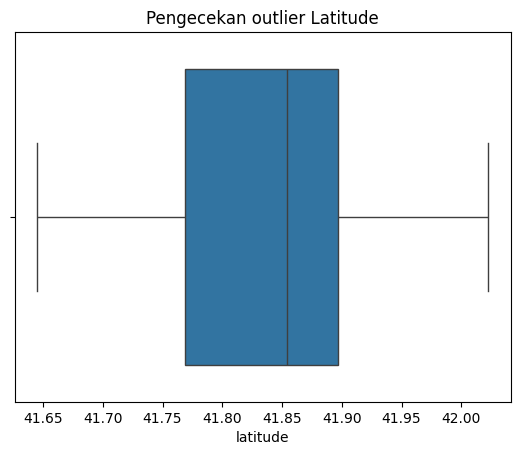

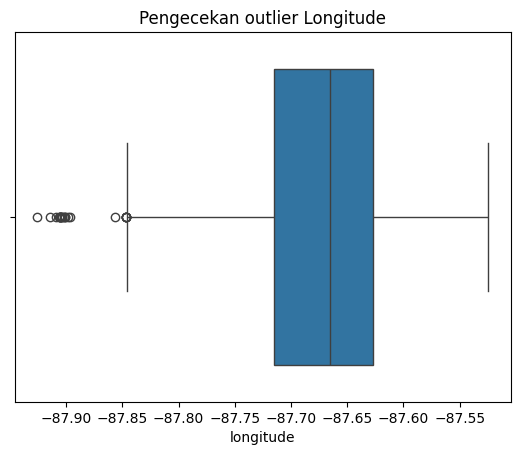

In [8]:
sns.boxplot(x=data['latitude'])
plt.title('Pengecekan outlier Latitude')
plt.show()

sns.boxplot(x=data['longitude'])
plt.title('Pengecekan outlier Longitude')
plt.show()

Berdasarkan hasil pengecekan outlier menggunakan visualisasi boxplot, ditemukan outlier pada variabel Longitude yang ditunjukkan oleh titik-titik di luar whisker. 

## Validasi Data

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70329 entries, 0 to 70747
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   primary_type  70329 non-null  object 
 1   date          70329 non-null  object 
 2   arrest        70329 non-null  bool   
 3   year          70329 non-null  int64  
 4   latitude      70329 non-null  float64
 5   longitude     70329 non-null  float64
 6   description   70329 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(3)
memory usage: 3.8+ MB


In [10]:
data.describe()

,year,latitude,longitude
count,70329.000000,70329.000000,70329.000000
mean,2017.284179,41.838929,-87.669977
std,1.619954,0.081490,0.055966
min,2015.000000,41.645288,-87.925509
25%,2016.000000,41.768687,-87.714951
50%,2017.000000,41.854039,-87.665016
75%,2019.000000,41.896889,-87.627517
max,2020.000000,42.022549,-87.524541


## **Analisis Data Eksploratif**

### Analisis 1 - Heatmap

Visualisasi heatmap digunakan untuk mengidentifikasi hubungan natara numerik dalam dataset. Visualisasi heatmap dipilih karena dapat menampilkan kekuatan korelasi antar variabel secara visual dan mudah dipahami. 

Variabel yang digunakan dalam visualisasi ini adalah variabel primary_type dan year. Variabel primary_type merepresentasikan jenis kejahatan dan variabel year yang merepresentasikan dimensi waktu. Crosstab digunakan untuk menghotung frekuensi kejadian dari kombinasi dua variabel tersebut.

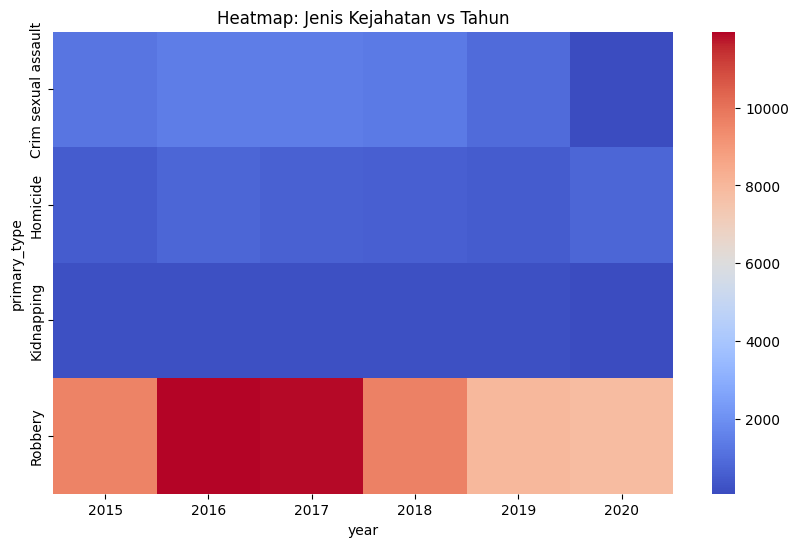

In [13]:
pivot = pd.crosstab(data['primary_type'], data['year'])

plt.figure(figsize=(10,6))

sns.heatmap(pivot, cmap='coolwarm')
plt.title('Heatmap: Jenis Kejahatan vs Tahun')
plt.xlabel('year')
plt.ylabel('primary_type')

plt.show()

Berdasarkan hasil visualisasi heatmap, ditemukan bahwa jenis kejahatan yang terjadi di kota Chicago periode 2015-2020 memiliki pola yang berbeda-beda. Jenis kejahatan Robbery menunjukkan jumlah kasus yang relatif tinggi pada tahun 2016-2017 serta mengalami penurunan pada tahun 2019-2020. Sementara itu, jenis kejahatan Kidnapping dan Homicide cenderung stabil pada sepanjang periode 2015-2020. Disisi lain, jenis kejagatan Criminal sexual assault memiliki jumlah relatif yang relatif rendah dibandingkan jenis kejahatan lainnya.

### Analisis 2 - Bar Plot

Text(0.5, 1.05, 'Jumlah Kejahatan per Tahun berdasarkan Status Penangkapan')

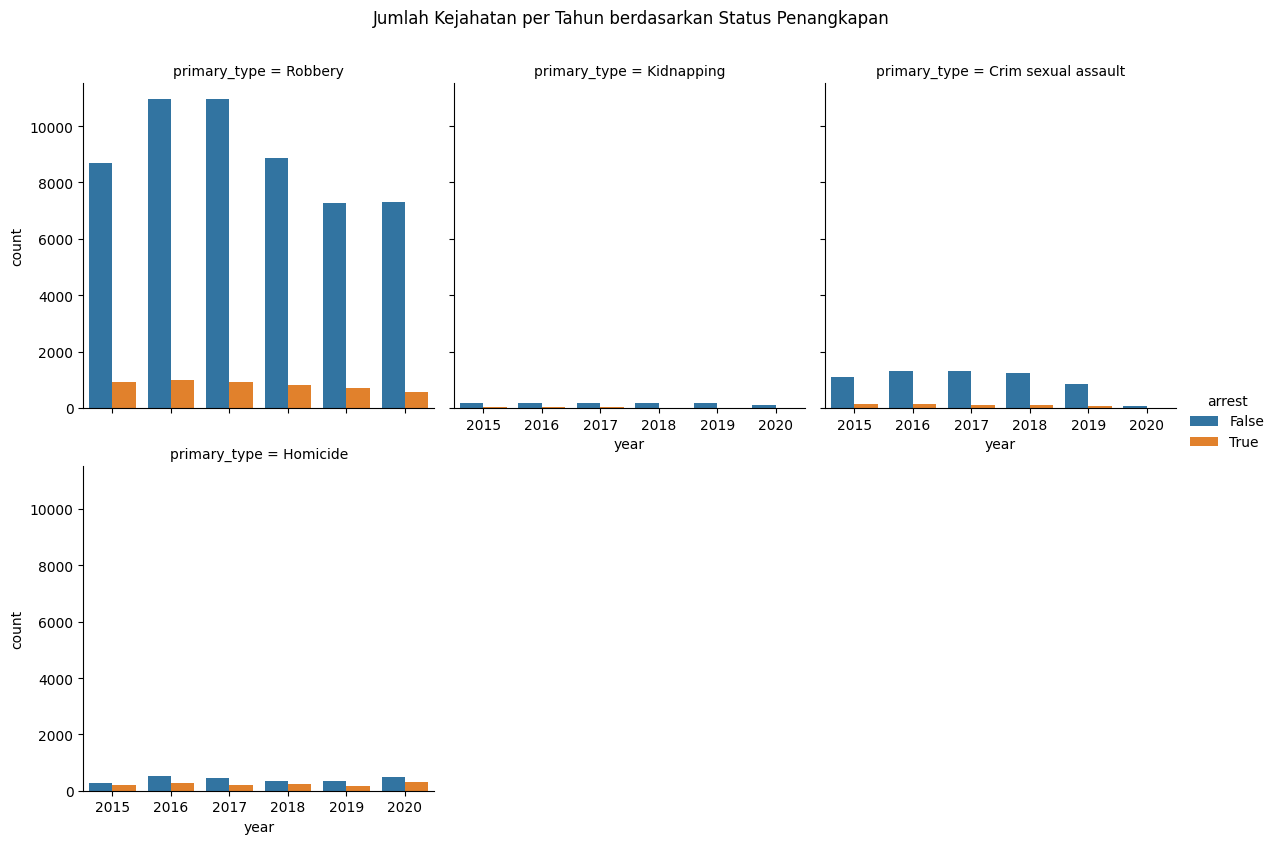

In [18]:
top5 = data['primary_type'].value_counts().head(5).index
df_top = data[data['primary_type'].isin(top5)]

grafik = sns.catplot(
    x='year',
    hue='arrest',
    col='primary_type',
    data=df_top,
    kind='count',
    col_wrap=3,
    height=4
)

grafik.fig.suptitle('Jumlah Kejahatan per Tahun berdasarkan Status Penangkapan', y=1.05)

Berdasarkan hasil visualisasi, ditemukan bahwa sebagian besar jenis kejahatan yang terdapat di kota Chicago menunjukkan bahwa kasus dimana pelaku kejahatan tidak berhasil ditangkap lebih tinggi dibandingkan dengan kasus kejahatan yang pelakunya berhasil ditangkap. Hal ini sangat ditunjukkan pada jenis kasus Robbery memiliki jumlah kejadian tertinggi namun tingkat penangkapannya relatif rendah. Sementara itu, kasus Homicide menunjukkan pola yang berbeda yaitu dengan perbandingan yang seimbang antara kasus yang pelakunya tertangkap dan yang tidak tertangkap. 

### Analisis 3 - Line Plot

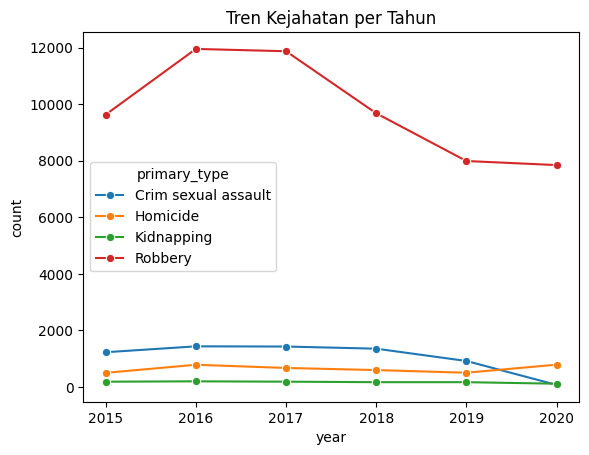

In [23]:
top4 = data['primary_type'].value_counts().head(4).index
df_top = data[data['primary_type'].isin(top4)]

trend = df_top.groupby(['year', 'primary_type']).size().reset_index(name='count')

sns.lineplot(x='year', y='count', hue='primary_type', data=trend, marker='o')

plt.title('Tren Kejahatan per Tahun')
plt.show()

Berdasarkan hasil visualisasi Line Plot, menunjukkan bahwa jenis Kejahatan Robbery merupakan jenis kejahatan dengan jumlah paling tinggi dibandingkan jumlah jenis kejahatan lainnya. Puncak tertinggi kasus kejahatan robbery pada tahun 2016-2017 sebelum mengalami penurunan hingga tahun 2020. Sementara itu, jenis kejahatan Criminal sexual assault menunjukkan penurunan jumlah kasus secara bertahap tiap tahunnya. Berbeda dengan jenis kejahatan Homicide yang menunjukkan jumlah kasus yang naik turun (fluktuatif), sedangkan jenis kejahatan kidnapping relatif stabis jumlah kasusnya sepanjang periode 2015-2020.

### Analisis 4 - Boxplot

Visualisasi Boxplot digunakan untuk membandingkan distribusi variabel numerik berdasarkan kategori tertentu. Visualisasi boxplot dipilih karena dapat menunjukkan perbedaan distribusi, median, dan variasi data antar kelompok. 

Variabel yang digunakan dalam analisis ini adalah variabel primary_type, latitude, dan longitude.

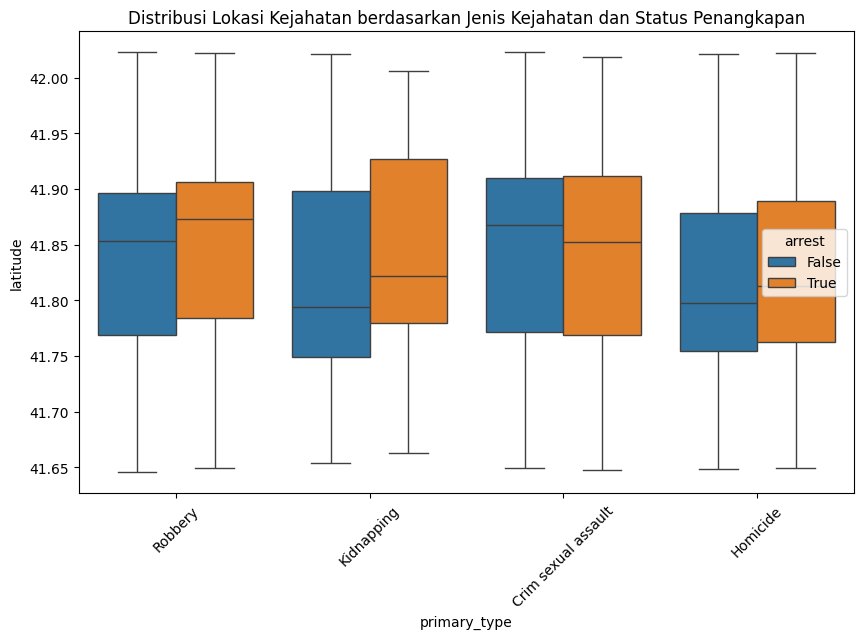

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(x='primary_type', y='latitude', hue='arrest', data=data)

plt.xticks(rotation=45)
plt.title('Distribusi Lokasi Kejahatan berdasarkan Jenis Kejahatan dan Status Penangkapan')
plt.xlabel('primary_type')
plt.ylabel('latitude')

plt.show()

Berdasarkan visualisasi boxplot latitude, ditunjukkan bahwa distribusi lokasi kejahatan untuk seluruh jenis kejahatan berada pada rentang yang relatif sama yaitu sekitar 41.78 hingga 41.88. Hal ini menunjukkan bahwa secara geografis latitude (arah utara dan selatan) pusat tindakan kejahatan cenderung terjadi pada area yang sama. Selain itu, rentang IQR pada masing-masing kategori yang cukup lebar menunjukkan bahwa tindakan kejahatan tidak hanya terjadi pada satu titik tetapi menyebar luas meski masih dalam satu area utama. Perbandingan antara status penangkapan menunjukkan pola yang hampir identik sehingga keberhasilan penangkapan tidak memiliki hubungan yang kuat dengan posisi latitude kejadian. 

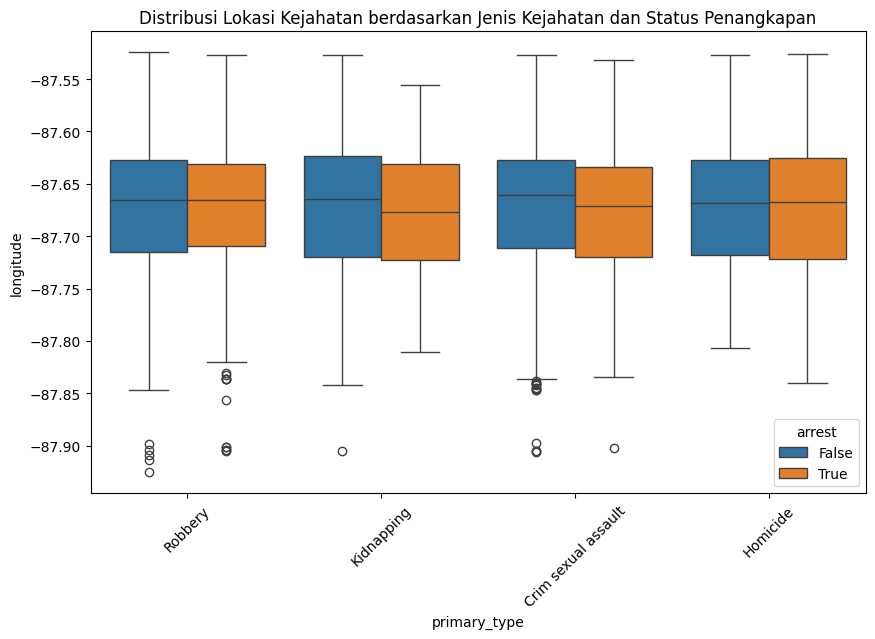

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(x='primary_type', y='longitude', hue='arrest', data=data)

plt.xticks(rotation=45)
plt.title('Distribusi Lokasi Kejahatan berdasarkan Jenis Kejahatan dan Status Penangkapan')
plt.xlabel('primary_type')
plt.ylabel('longitude')

plt.show()

Hasil visualisasi boxplot longitude menunjukkan bahwa seluruh tindak kejahatan berada pada rentang yang sama, disekitar -87.70 hingga -87.65. Rentang tersebut menunjukkan bahwa secara arah barat-timur lokasi kejahatan terkonsentrasi pada wilayah yang sama. Hasil visualisasi boxplot menunjukkan terdapat beberapa outlier yang cukup banyak, hal ini menunjukkan bahwa beberapa tindak kejahatan ada yang terjadi di lokasi yang terjadi di luar area utama. Selain itu, hasil menunjukkan bahwa tidak terdapat perbedaan signifikan antara kasus dengan penangkapan yang berhasil dan penangkapan yang tidak berhasil. Hal ini menunjukkan bahwa faktor longitude tidak berpengaruh besar terhadap berhasil dan gagalnya penangkapan pelaku tindak kejahatan. 

### Analisis 5 - Scatter Plot

Visualisasi Scatter plot digunakan untuk menunjukkan hubungan antara dua variabel numerik sehingga dapat digunakan untuk menunjukkan distribusi spasial kejadian kejahatan. 

Variabel yang digunakan dalam analisis ini adalah Variabel numerik Latitude dan Longitude, variabel year yang digunakan sebagai dimensi tambahan  

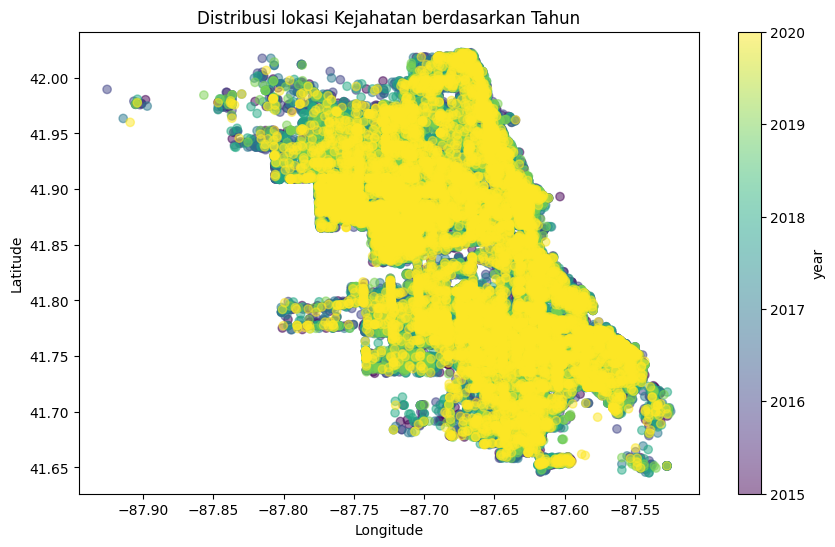

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(data['longitude'], data['latitude'], c=data['year'], cmap='viridis', alpha=0.5)
plt.colorbar(label='year')

plt.title('Distribusi lokasi Kejahatan berdasarkan Tahun')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

Hasil visualisasi Scatter plot merepresentasikan distribusi lokasi kejahatan berdasarkan koordinat latitude dan longitude dengan warna yang menunjukkan periode 2015-2020. Latitude menunjukkan arah utara dan selatan wilayah Chicago dan Longitude menunjukkan arah barat dan timur wilayah Chicago.

Visualisasi menunjukkan bahwa titik titik yang merepresentasikan data sangat padat serta terkonsentrasi pada area tengah peta menunjukkan bahwa tindak kejahatan sering terjadi secara berulang pada di lokasi yang berdekatan atau sama. Selain itu, distribusi warna yang saling bercampur tanpa gradasi yang jelas menunjukkan bahwa selama periode 2015-2020 tidak menunjukkan perubahan lokasi yang signifikan. Artinya lokasi tindak kejahatan memiliki pola lokasi yang stabil selama periode 2015-2020 dan cenderung terpusat pada area tertentu dengan intensitas tinggi.